# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline


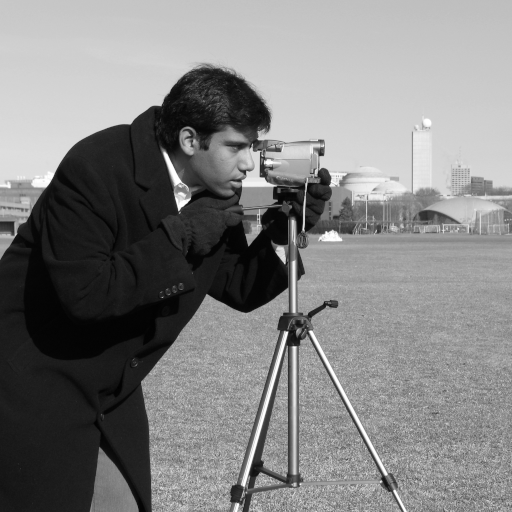

In [2]:
# ── Load image ────────────────────────────────────
original_image = Image.fromarray(data.camera())
original_image 

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = original_image.size

# scaling factors
scale_x = 2
scale_y = 2

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_image = original_image.resize(
    (width * scale_x, height * scale_y),
    Image.Resampling.LANCZOS
)

Original size: (512, 512)
Scaled size: (1024, 1024)


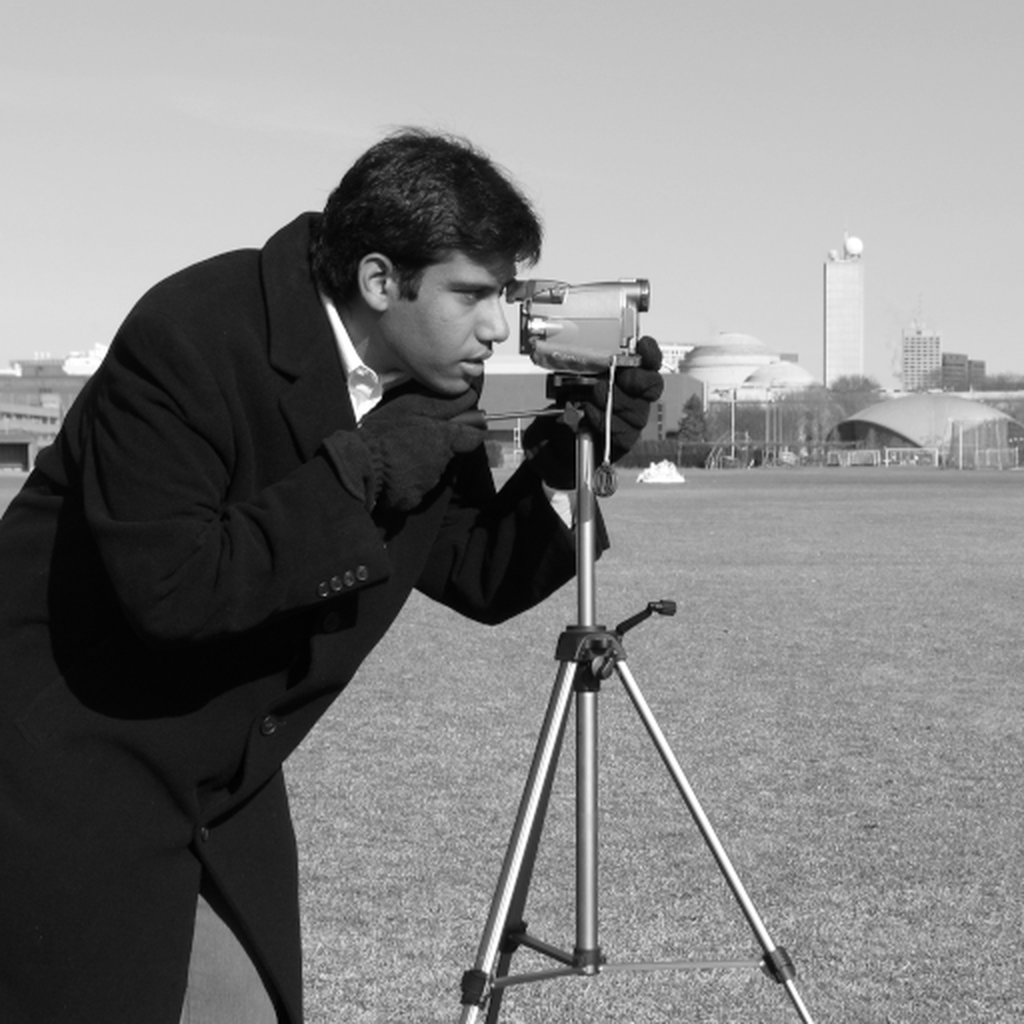

In [5]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_1_scaled.jpg")
print("Original size:", original_image.size)
print("Scaled size:", scaled_image.size)
scaled_image

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
# Get the size of the image
width, height = original_image.size

# scaling factors
scale_x = 2
scale_y = 1

In [7]:
# Resize the image using PIL's built-in method
scaled_image2= original_image.resize(
    (width * scale_x, height * scale_y),
    Image.Resampling.LANCZOS
)

Original size: (512, 512)
Scaled size: (1024, 512)


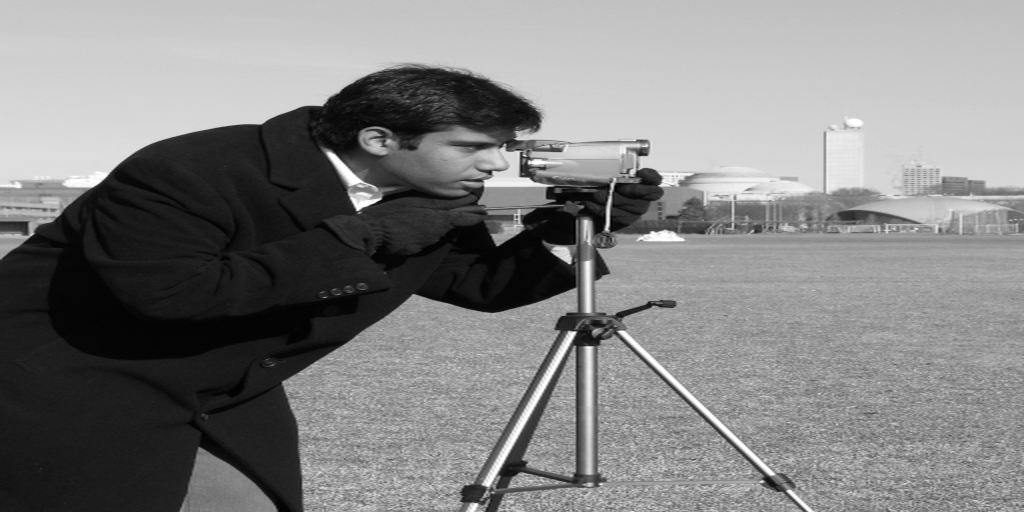

In [8]:
# Save the scaled image and print the sizes 
scaled_image2.save("task1_12_scaled.jpg")
print("Original size:", original_image.size)
print("Scaled size:", scaled_image2.size)
scaled_image2

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (512, 512)


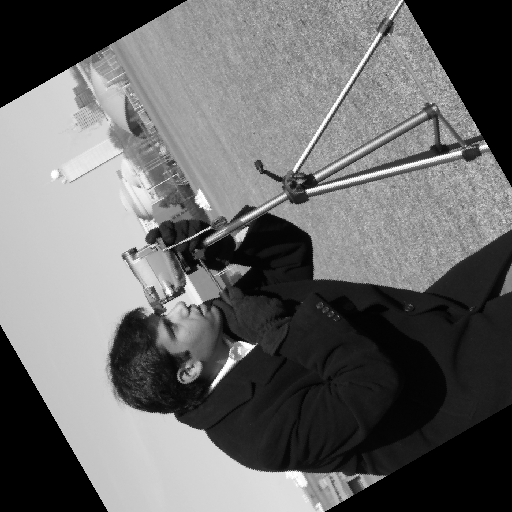

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image = original_image.rotate(120) # .rotate(degree)

rotated_image.save("task1_2_rotated.jpg")

print("Original size:", original_image.size)
print("Rotated size:", rotated_image.size)
rotated_image

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = original_image.size
print(width,",", height)

512 , 512


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

shear_matrix = [
    1, shear_factor, 0,
    0, 1, 0
]

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared_image = original_image.transform(
    original_image.size,
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)


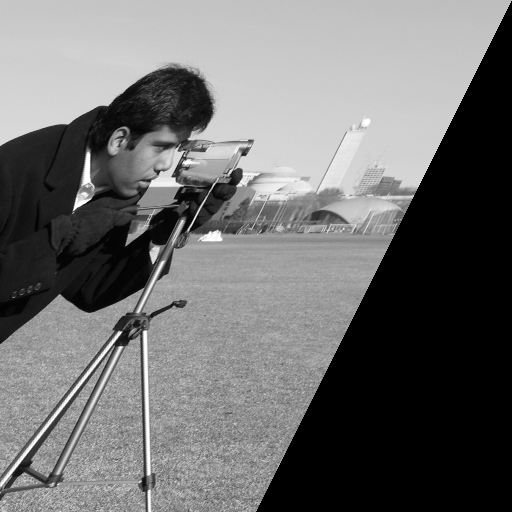

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("task1_3_sheared.jpg")
sheared_image

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

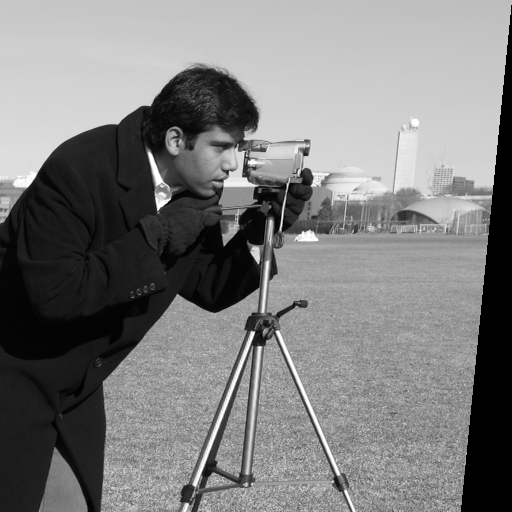

In [14]:
shear_factor = 0.1

shear_matrix = [
    1, shear_factor, 0,
    0, 1, 0
]

sheared_image = original_image.transform(
    original_image.size,
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

sheared_image

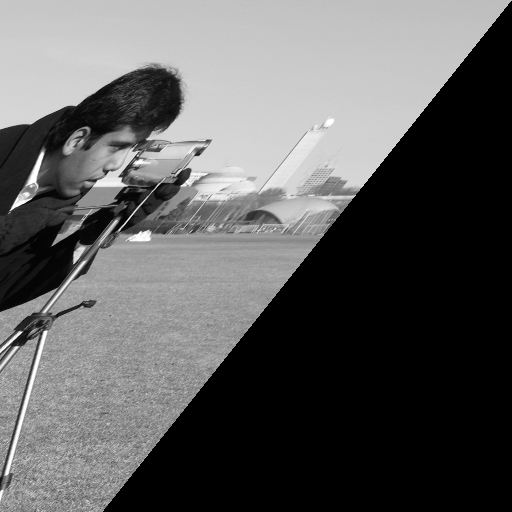

In [15]:
shear_factor = 0.8

shear_matrix = [
    1, shear_factor, 0,
    0, 1, 0
]

sheared_image = original_image.transform(
    original_image.size,
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

sheared_image

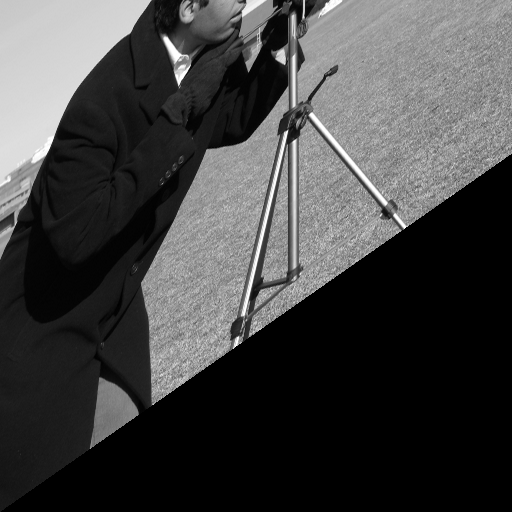

In [16]:
shear_factor = 0.7

shear_matrix = [
    1, 0, 0,
    shear_factor, 1, 0
]

sheared_image = original_image.transform(
    original_image.size,
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

sheared_image

# Intensity Transformations
Negative · Log · Power Law (Gamma)

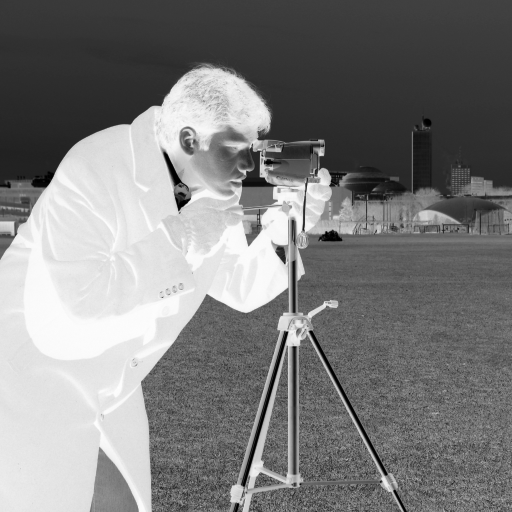

In [24]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

img_array = np.asarray(original_image) # convert PIL object back into np array

negative = 255 - img_array
# Dark pixels become bright, and bright pixels become dark.

negative_image = Image.fromarray(negative)

negative_image

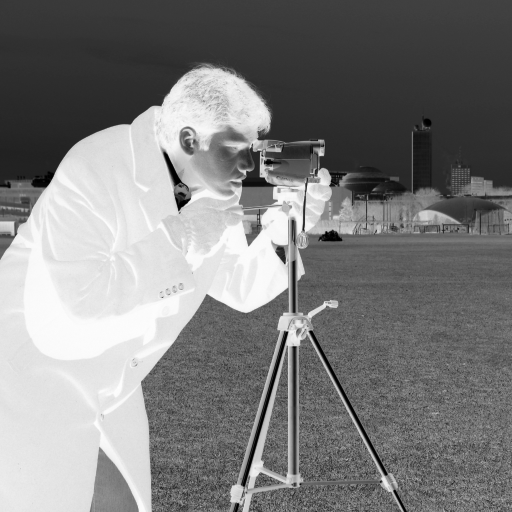

In [27]:
# Method 2: PIL's ImageOps
# same result as numpy array method
from PIL import ImageOps

negative_image = ImageOps.invert(original_image)

negative_image

C:\Users\N\AppData\Local\Temp\ipykernel_29904\3406401203.py:15: RuntimeWarning: divide by zero encountered in log
  log_image = c * np.log(1 + img_array)
C:\Users\N\AppData\Local\Temp\ipykernel_29904\3406401203.py:18: RuntimeWarning: invalid value encountered in cast
  log_image = np.uint8(log_image)


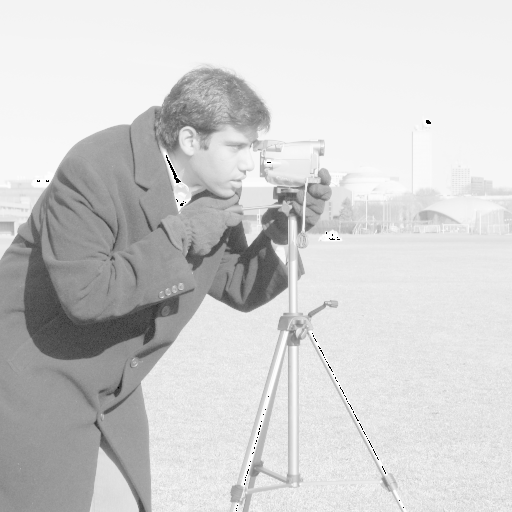

In [31]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

# calc c
c = 255 / np.log(1 + 255)

# convert to array
img_array = np.asarray(original_image) 

# Apply the log transformation to each pixel
log_image = c * np.log(1 + img_array)

# Convert back to uint8
log_image = np.uint8(log_image)

# Convert to PIL Image
log_image = Image.fromarray(log_image)

log_image

# Log transformation makes dark pixels brighter while compressing the brighter intensity values,
# so details in dark areas become more visible.

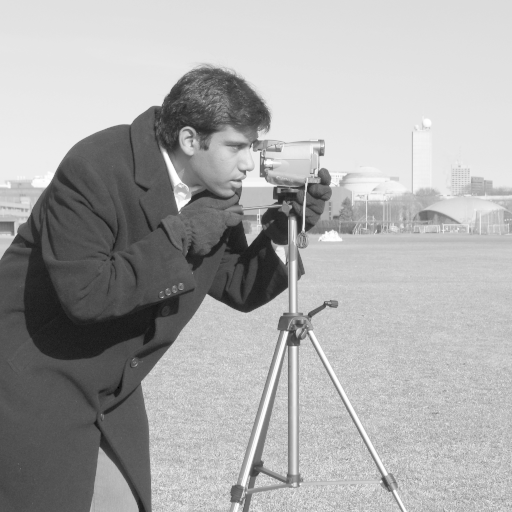

In [36]:

# ── 3. Power-law / Gamma correction ───────────────
# law: s=c⋅rγ

# gamma<1 makes the image brighter\
gamma = 0.5

# / 255.0 is to normalize image to 0-1, otherwise output will be realy noizy and bad
img_array=np.asarray(original_image)/ 255.0

# gamma transformation
gamma_img=np.power(img_array, gamma)

# convert img back to 0-255 range, then back to PIL image
gamma_img=np.uint8(gamma_img * 255)
gamma_img=Image.fromarray(gamma_img)

gamma_img